In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train = pd.read_csv("../data/train.csv", parse_dates=["date"])
stores = pd.read_csv("../data/stores.csv")
oil = pd.read_csv("../data/oil.csv", parse_dates=["date"])
holidays = pd.read_csv("../data/holidays_events.csv", parse_dates=["date"])

print(train.shape)
train.head()

(3000888, 6)


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [10]:
print(train.isnull().sum())
print(oil.isnull().sum())

id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64
date           0
dcoilwtico    43
dtype: int64


In [11]:
oil["dow"] = oil["date"].dt.day_name()
oil[oil["dcoilwtico"].isnull()]["dow"].value_counts()

dow
Monday       23
Friday        9
Thursday      7
Tuesday       2
Wednesday     2
Name: count, dtype: int64

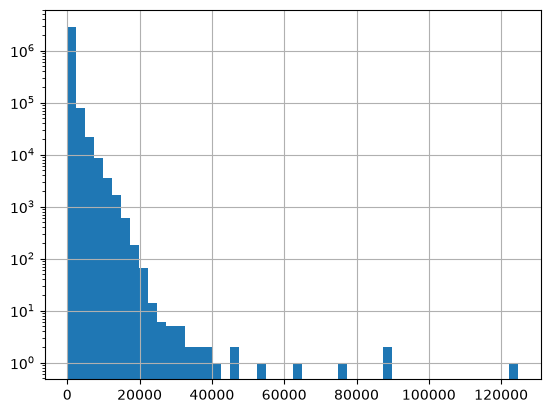

In [12]:
train["sales"].describe()
train["sales"].hist(bins=50, log=True)
plt.show()

In [13]:
(train["sales"] == 0).mean()

np.float64(0.3129506999261552)

In [14]:
zero_by_pair = train.groupby(["store_nbr", "family"])["sales"].apply(lambda s: (s == 0).mean())

print("Toplam mağaza-ürün ailesi kombinasyonu:", len(zero_by_pair))
print("Hiç satılmamış (her zaman sıfır):", (zero_by_pair == 1.0).sum())
print("Hiç sıfır olmayan (her zaman satılmış):", (zero_by_pair == 0.0).sum())

zero_by_pair.sort_values(ascending=False).head(10)

Toplam mağaza-ürün ailesi kombinasyonu: 1782
Hiç satılmamış (her zaman sıfır): 53
Hiç sıfır olmayan (her zaman satılmış): 0


store_nbr  family   
54         BOOKS        1.0
50         BABY CARE    1.0
49         BABY CARE    1.0
47         BABY CARE    1.0
46         BABY CARE    1.0
48         BABY CARE    1.0
52         BOOKS        1.0
45         BABY CARE    1.0
44         BABY CARE    1.0
43         BOOKS        1.0
Name: sales, dtype: float64

In [15]:
always_zero = zero_by_pair[zero_by_pair == 1.0]
always_zero.reset_index()["family"].value_counts()

family
BOOKS              28
BABY CARE          12
LADIESWEAR         10
LAWN AND GARDEN     3
Name: count, dtype: int64

In [16]:
daily_sales = train.groupby("date")["sales"].sum().reset_index()
merged = daily_sales.merge(oil, on="date", how="left")
merged["dcoilwtico"] = merged["dcoilwtico"].ffill()  # eksikleri bir önceki günle doldur
merged[["sales", "dcoilwtico"]].corr()

,sales,dcoilwtico
sales,1.000000,-0.626856
dcoilwtico,-0.626856,1.000000


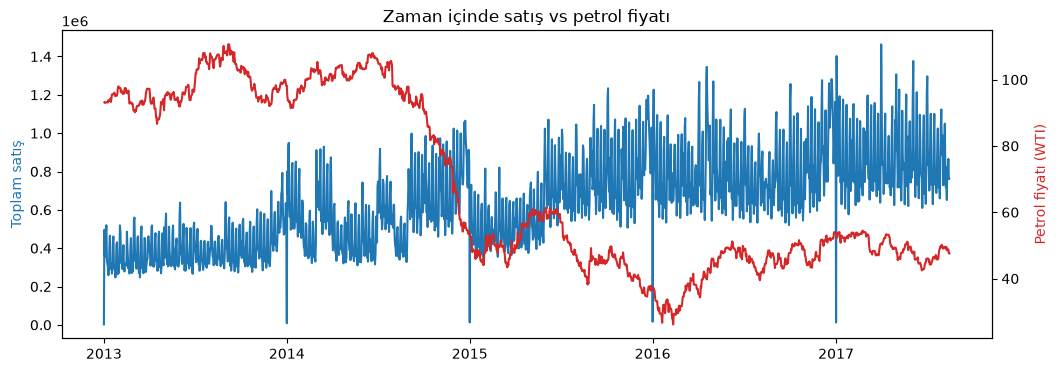

In [17]:
fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(merged["date"], merged["sales"], color="tab:blue")
ax1.set_ylabel("Toplam satış", color="tab:blue")

ax2 = ax1.twinx()
ax2.plot(merged["date"], merged["dcoilwtico"], color="tab:red")
ax2.set_ylabel("Petrol fiyatı (WTI)", color="tab:red")

plt.title("Zaman içinde satış vs petrol fiyatı")
plt.show()

In [20]:
""" Bulgular
1. 3.000.888 satır, eksik veri yok (train). Petrol verisinde 43 eksik gün —
   sistemli (çoğunlukla Pazartesi'ler, ABD piyasa tatilleri) — ffill ile doldurulacak.
2. Satış dağılımı şiddetli sağa çarpık, %31 sıfır satış. Bunun 53 kombinasyonu
   (çoğu BOOKS/BABY CARE) "yapısal sıfır" — o mağaza o ürünü hiç satmıyor.
3. Petrol fiyatı ile toplam satış arasında güçlü negatif korelasyon (-0.63) VAR
   ama muhtemelen sahte — ikisi de kendi trendini takip ediyor (satış büyüyor,
   petrol 2014-16 çöküyor), zaman grafiğinde teyit edildi. Ham korelasyona
   güvenilmez, trend çıkarılmadan yorumlanmamalı.
4. Yıl başlarında (1 Ocak) satış sıfıra düşüyor — tatil etkisi gözle görünür,
   holidays_events.csv Hf2'de feature olarak eklenecek.
"""

' Bulgular\n1. 3.000.888 satır, eksik veri yok (train). Petrol verisinde 43 eksik gün —\n   sistemli (çoğunlukla Pazartesi\'ler, ABD piyasa tatilleri) — ffill ile doldurulacak.\n2. Satış dağılımı şiddetli sağa çarpık, %31 sıfır satış. Bunun 53 kombinasyonu\n   (çoğu BOOKS/BABY CARE) "yapısal sıfır" — o mağaza o ürünü hiç satmıyor.\n3. Petrol fiyatı ile toplam satış arasında güçlü negatif korelasyon (-0.63) VAR\n   ama muhtemelen sahte — ikisi de kendi trendini takip ediyor (satış büyüyor,\n   petrol 2014-16 çöküyor), zaman grafiğinde teyit edildi. Ham korelasyona\n   güvenilmez, trend çıkarılmadan yorumlanmamalı.\n4. Yıl başlarında (1 Ocak) satış sıfıra düşüyor — tatil etkisi gözle görünür,\n   holidays_events.csv Hf2\'de feature olarak eklenecek.\n'